In [ ]:
%pip install numpy
%pip install scikit-learn
%pip install pandas
%pip install matplotlib

In [87]:
import numpy as np
import pandas as pd

import matplotlib

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC, SVR, LinearSVC, LinearSVR, NuSVC, NuSVR, OneClassSVM
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report


In [197]:
def display_df_info(*args):
    for arg in args:
        print(arg.head())
        print("Shape:", arg.shape)

In [198]:
train_df = pd.read_csv('training_dataset.csv')
test_blackscholes_df = pd.read_csv('testing_blackscholes.csv')
test_bodytrack_df = pd.read_csv('testing_bodytrack.csv')
display_df_info(train_df, test_blackscholes_df, test_bodytrack_df)

   total_watts     w_big  w_little     w_gpu     w_mem  usage_c4  usage_c5  \
0        3.065  0.474810  0.033012  0.096321  0.048800       0.0       0.0   
1        2.706  0.235620  0.032095  0.096515  0.032940       0.0       0.0   
2        2.706  0.235620  0.034846  0.096515  0.032940       0.0       0.0   
3        2.637  0.234685  0.034846  0.096321  0.037758       0.0       0.0   
4        2.637  0.233750  0.033929  0.096321  0.032886       0.0       0.0   

   usage_c6  usage_c7  temp4  temp5  temp6  temp7  temp_gpu  freq_big_cluster  
0       0.0       0.0     49     53     52     48        47        1000000000  
1       0.0       0.0     48     52     52     48        47        1000000000  
2       0.0       0.0     48     52     52     48        47        1000000000  
3       0.0       0.0     48     51     51     48        47        1000000000  
4       0.0       0.0     48     51     51     48        47        1000000000  
Shape: (5415, 15)
   total_watts     w_big  w_littl

In [99]:
def feature_engineering(df):
    df["temp4"] /= 100
    df["temp5"] /= 100
    df["temp6"] /= 100
    df["temp7"] /= 100
    df["temp_gpu"] /= 100
    df["freq_big_cluster"] /= 1e9

In [200]:
X_train = train_df.drop("w_big", axis=1)
y_train = (train_df["w_big"] > 1).astype(int)
feature_engineering(X_train)


X_test_bs = test_blackscholes_df.drop("w_big", axis=1)
y_test_bs = (test_blackscholes_df["w_big"] > 1).astype(int)
feature_engineering(X_test_bs)

X_test_bt = test_bodytrack_df.drop("w_big", axis=1)
y_test_bt = (test_bodytrack_df["w_big"] > 1).astype(int)
feature_engineering(X_test_bt)

display_df_info(X_train, y_train, X_test_bs, y_test_bs, X_test_bt, y_test_bt)

   total_watts  w_little     w_gpu     w_mem  usage_c4  usage_c5  usage_c6  \
0        3.065  0.033012  0.096321  0.048800       0.0       0.0       0.0   
1        2.706  0.032095  0.096515  0.032940       0.0       0.0       0.0   
2        2.706  0.034846  0.096515  0.032940       0.0       0.0       0.0   
3        2.637  0.034846  0.096321  0.037758       0.0       0.0       0.0   
4        2.637  0.033929  0.096321  0.032886       0.0       0.0       0.0   

   usage_c7  temp4  temp5  temp6  temp7  temp_gpu  freq_big_cluster  
0       0.0   0.49   0.53   0.52   0.48      0.47               1.0  
1       0.0   0.48   0.52   0.52   0.48      0.47               1.0  
2       0.0   0.48   0.52   0.52   0.48      0.47               1.0  
3       0.0   0.48   0.51   0.51   0.48      0.47               1.0  
4       0.0   0.48   0.51   0.51   0.48      0.47               1.0  
Shape: (5415, 14)
0    0
1    0
2    0
3    0
4    0
Name: w_big, dtype: int64
Shape: (5415,)
   total_watts  w

In [101]:
print("Train positive rate:", y_train.mean())
print("Blackscholes positive rate:", y_test_bs.mean())
print("Bodytrack positive rate:", y_test_bt.mean())
train_df.corr()['w_big']

Train positive rate: 0.3327793167128347
Blackscholes positive rate: 0.6642468239564429
Bodytrack positive rate: 0.624484181568088


total_watts         0.998448
w_big               1.000000
w_little            0.851071
w_gpu               0.841926
w_mem               0.453570
usage_c4            0.208438
usage_c5            0.241227
usage_c6            0.216145
usage_c7            0.232910
temp4               0.921138
temp5               0.920002
temp6               0.889142
temp7               0.885766
temp_gpu            0.865410
freq_big_cluster    0.744363
Name: w_big, dtype: float64

In [ ]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC())
])
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [103]:
model2 = Pipeline([
    ("scaler", MinMaxScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma=0.1
    ))
])
model2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.1


In [108]:
model3 = SVC(
    kernel='rbf',
    C=100,
    gamma='scale',
    class_weight='balanced'
)

model3.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


Blackscholes
Accuracy: 0.9975801572897761
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       555
           1       1.00      1.00      1.00      1098

    accuracy                           1.00      1653
   macro avg       1.00      1.00      1.00      1653
weighted avg       1.00      1.00      1.00      1653



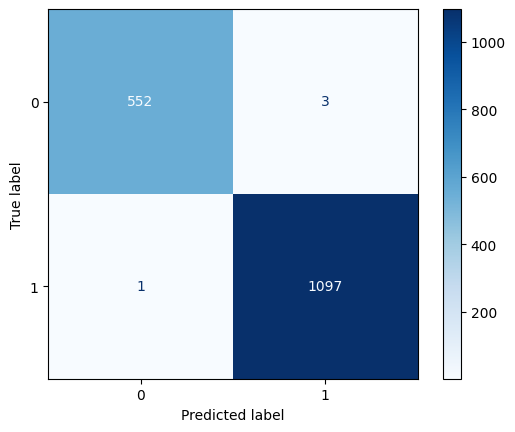

In [110]:
y_pred_bs = model3.predict(X_test_bs)
print("Blackscholes")
print("Accuracy:", accuracy_score(y_test_bs, y_pred_bs))
ConfusionMatrixDisplay.from_estimator(model3, X_test_bs, y_test_bs, cmap='Blues')
print(classification_report(y_test_bs, y_pred_bs, zero_division=0))

Bodytrack
Accuracy: 0.9951856946354883
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       546
           1       0.99      1.00      1.00       908

    accuracy                           1.00      1454
   macro avg       1.00      0.99      0.99      1454
weighted avg       1.00      1.00      1.00      1454



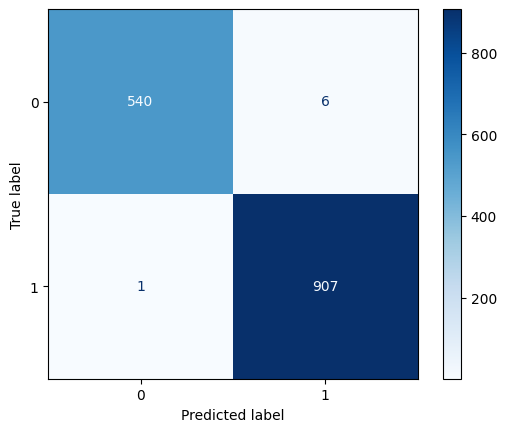

In [111]:
y_pred_bt = model3.predict(X_test_bt)
print("Bodytrack")
print("Accuracy:", accuracy_score(y_test_bt, y_pred_bt))
ConfusionMatrixDisplay.from_estimator(model3, X_test_bt, y_test_bt, cmap='Blues')
print(classification_report(y_test_bt, y_pred_bt, zero_division=0))

In [147]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot as plt

In [199]:
X_train_q2 = train_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_train_q2 = train_df["w_big"]

X_test_bs_q2 = test_blackscholes_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_test_bs_q2 = test_blackscholes_df["w_big"]

X_test_bt_q2 = test_bodytrack_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_test_bt_q2 = test_bodytrack_df["w_big"]

display_df_info(X_train_q2, X_test_bs_q2, X_test_bt)

   usage_c4  usage_c5  usage_c6  usage_c7  temp4  temp5  temp6  temp7  \
0       0.0       0.0       0.0       0.0     49     53     52     48   
1       0.0       0.0       0.0       0.0     48     52     52     48   
2       0.0       0.0       0.0       0.0     48     52     52     48   
3       0.0       0.0       0.0       0.0     48     51     51     48   
4       0.0       0.0       0.0       0.0     48     51     51     48   

   temp_gpu  freq_big_cluster  
0        47        1000000000  
1        47        1000000000  
2        47        1000000000  
3        47        1000000000  
4        47        1000000000  
Shape: (5415, 10)
   usage_c4  usage_c5  usage_c6  usage_c7  temp4  temp5  temp6  temp7  \
0       0.0       0.0       0.0    0.0000     57     61     61     57   
1       0.0       0.0       0.0    0.0000     57     61     60     57   
2       0.0       0.0       0.0    0.1875     57     61     60     57   
3       0.0       0.0       0.0    0.0000     57     61    

In [ ]:
model_q2 = LinearRegression()
model_q2.fit(X_train_q2, y_train_q2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [185]:
print("Training")
y_train_q2_pred = model_q2.predict(X_train_q2)
r2 = model_q2.score(X_train_q2, y_train_q2)
mse = mean_squared_error(y_train_q2, y_train_q2_pred)
print("R2:", r2)
print("MSE:", mse)

Training
R2: 0.9869761626648631
MSE: 0.010151781665943502


In [183]:
print("Blackscholes")
y_pred_bs_q2 = model_q2.predict(X_test_bs_q2)
r2 = model_q2.score(X_test_bs_q2, y_test_bs_q2)
mse = mean_squared_error(y_test_bs_q2, y_pred_bs_q2)
print("R2:", r2)
print("MSE:", mse)


Blackscholes
R2: 0.956626982694395
MSE: 0.05941814463692005


In [184]:
print("Bodytrack")
y_pred_bt_q2 = model_q2.predict(X_test_bt_q2)
r2 = model_q2.score(X_test_bt_q2, y_test_bt_q2)
mse = mean_squared_error(y_test_bt_q2, y_pred_bt_q2)
print("R2:", r2)
print("MSE:", mse)


Bodytrack
R2: 0.9224313626739923
MSE: 0.12156465960811984


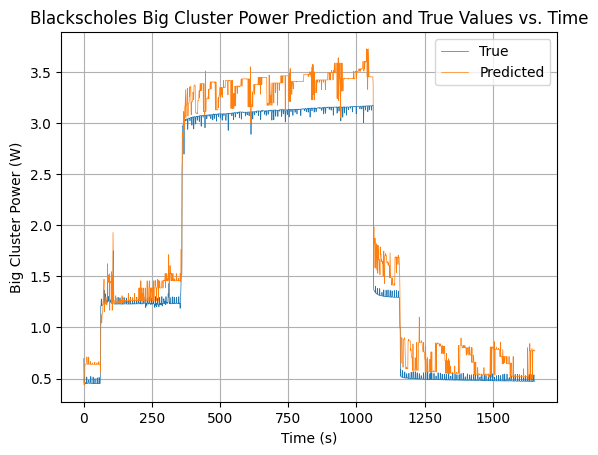

In [159]:
plt.figure(1)
x = np.arange(1, y_test_bs_q2.shape[0] + 1)
plt.plot(x, y_test_bs_q2, label="True", linewidth=0.5)
plt.plot(x, y_pred_bs_q2, label="Predicted", linewidth=0.5)
plt.title("Blackscholes Big Cluster Power Prediction and True Values vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Big Cluster Power (W)")
plt.grid()
plt.legend()
plt.show()

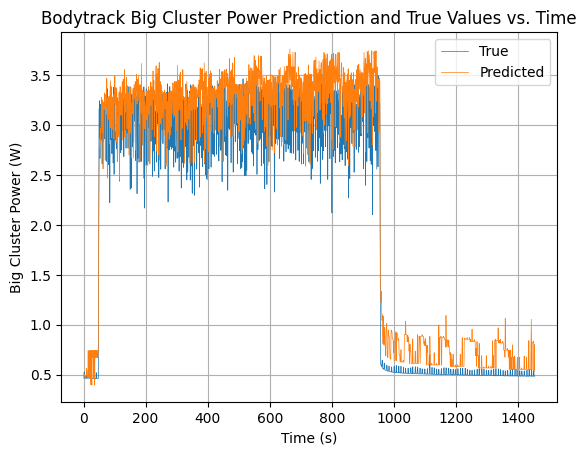

In [158]:
plt.figure(2)
x2 = np.arange(1, y_test_bt_q2.shape[0] + 1)
plt.plot(x2, y_test_bt_q2, label="True", linewidth=0.5)
plt.plot(x2, y_pred_bt_q2, label="Predicted", linewidth=0.5)
plt.title("Bodytrack Big Cluster Power Prediction and True Values vs. Time")
plt.xlabel("Time (s)")
plt.ylabel("Big Cluster Power (W)")
plt.grid()
plt.legend()
plt.show()

In [165]:
def feature_engineering_q3(df):
    mapping = {
        900000000 : 0.975,
        1000000000   : 1,
        1500000000 : 1.1375,
        2000000000   : 1.362
    }
    df["v2f"] = (df["freq_big_cluster"].map(mapping))**2 * df["freq_big_cluster"]

In [201]:
X_train_q3 = train_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_train_q3 = train_df["w_big"]
feature_engineering_q3(X_train_q3)

X_test_bs_q3 = test_blackscholes_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_test_bs_q3 = test_blackscholes_df["w_big"]
feature_engineering_q3(X_test_bs_q3)

X_test_bt_q3 = test_bodytrack_df[['usage_c4', 'usage_c5', 'usage_c6', 'usage_c7', 'temp4', 'temp5', 'temp6', 'temp7', 'temp_gpu', 'freq_big_cluster']]
y_test_bt_q3 = test_bodytrack_df["w_big"]
feature_engineering_q3(X_test_bt_q3)

display_df_info(X_train_q3, X_test_bs_q3, X_test_bt_q3)

   usage_c4  usage_c5  usage_c6  usage_c7  temp4  temp5  temp6  temp7  \
0       0.0       0.0       0.0       0.0     49     53     52     48   
1       0.0       0.0       0.0       0.0     48     52     52     48   
2       0.0       0.0       0.0       0.0     48     52     52     48   
3       0.0       0.0       0.0       0.0     48     51     51     48   
4       0.0       0.0       0.0       0.0     48     51     51     48   

   temp_gpu  freq_big_cluster           v2f  
0        47        1000000000  1.000000e+09  
1        47        1000000000  1.000000e+09  
2        47        1000000000  1.000000e+09  
3        47        1000000000  1.000000e+09  
4        47        1000000000  1.000000e+09  
Shape: (5415, 11)
   usage_c4  usage_c5  usage_c6  usage_c7  temp4  temp5  temp6  temp7  \
0       0.0       0.0       0.0    0.0000     57     61     61     57   
1       0.0       0.0       0.0    0.0000     57     61     60     57   
2       0.0       0.0       0.0    0.1875     57

In [192]:
model_q3 = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
model_q3.fit(X_train_q3, y_train_q3)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


Feature: usage_c4, Score: 0.02348
Feature: usage_c5, Score: 0.01572
Feature: usage_c6, Score: -0.00097
Feature: usage_c7, Score: 0.02974
Feature: temp4, Score: 1.00116
Feature: temp5, Score: 0.68157
Feature: temp6, Score: 0.21325
Feature: temp7, Score: 0.57254
Feature: temp_gpu, Score: -1.65602
Feature: freq_big_cluster, Score: -1.45737
Feature: v2f, Score: 1.51417


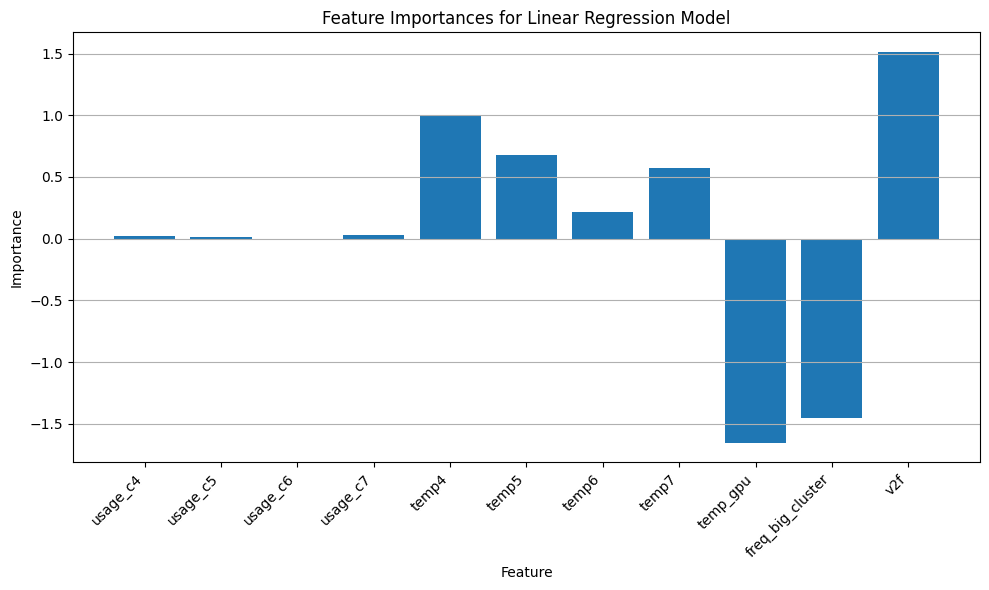

In [196]:
importance = model_q3.named_steps["lr"].coef_
feature_names = X_train_q3.columns

for name, score in zip(feature_names, importance):
    print(f'Feature: {name}, Score: {score:.5f}')

plt.figure(figsize=(10,6))
plt.bar([x for x in range(len(importance))], importance, tick_label=feature_names)
plt.title("Feature Importances for Linear Regression Model")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [194]:
print("Blackscholes")
y_pred_bs_q3 = model_q3.predict(X_test_bs_q3)
mse = mean_squared_error(y_test_bs_q3, y_pred_bs_q3)
# r2 = model_q2.score(X_test_bs_q3, y_test_bs_q3)
# print("R2:", r2)
print("MSE:", mse)


Blackscholes
MSE: 0.10313488598581896


In [195]:
print("Bodytrack")
y_pred_bt_q3 = model_q3.predict(X_test_bt_q3)
mse = mean_squared_error(y_test_bt_q3, y_pred_bt_q3)
# r2 = model_q3.score(X_test_bt_q3, y_test_bt_q3)
# print("R2:", r2)
print("MSE:", mse)


Bodytrack
MSE: 0.14142818181892006
